<a href="https://colab.research.google.com/github/nosadchiy/public/blob/main/JD_fulfillment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime, timedelta

In [8]:
order_url = 'https://www.dropbox.com/scl/fi/y6zcqqtsnsa6twhyi8vb7/JD_order_data.csv?rlkey=unjju7uoh01o667f8xrfy0crc&dl=1'
delivery_url = 'https://www.dropbox.com/scl/fi/haulquhvhtzjx4m626m65/JD_delivery_data.csv?rlkey=her1kd33a6lcmd2781cne05qz&dl=1'

order = pd.read_csv(order_url)
delivery = pd.read_csv(delivery_url)

# Data Preprocessing
order['promise_days'] = pd.to_numeric(order['promise'], errors='coerce')
# Fixed: Added format='mixed' to handle inconsistent datetime strings
order['order_time'] = pd.to_datetime(order['order_time'], format='mixed')
delivery['ship_out_time'] = pd.to_datetime(delivery['ship_out_time'], format='mixed')
delivery['arr_station_time'] = pd.to_datetime(delivery['arr_station_time'], format='mixed')
delivery['arr_time'] = pd.to_datetime(delivery['arr_time'], format='mixed')

# Merge datasets
del_data = pd.merge(order, delivery, on='order_ID', how='inner')
keepvars = ["order_ID", "order_time", "sku_ID", "quantity", "type_x", "promise_days", "dc_ori", "dc_des", "ship_out_time", "arr_station_time", "arr_time"]
# Note: pandas merge might name columns type_x or type_y depending on suffixes
del_data = del_data.rename(columns={'type.x': 'type_x'}) if 'type.x' in del_data.columns else del_data
del_data = del_data.dropna(subset=keepvars)

# Count SKU and sum quantity per order
items = del_data.groupby('order_ID').agg(sku_cnt=('sku_ID', 'count'), tot_qty=('quantity', 'sum')).reset_index()
del_data = pd.merge(del_data, items, on='order_ID')

# Keep one observation per order
del_data = del_data.drop_duplicates(subset='order_ID')
display(del_data.head())

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type_x,promise,original_unit_price,final_unit_price,...,dc_ori,dc_des,promise_days,package_ID,type_y,ship_out_time,arr_station_time,arr_time,sku_cnt,tot_qty
0,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40,1,1,2,99.9,53.9,...,28,28,2.0,7444318d01,1,2018-03-01 13:00:00,2018-03-02 08:00:00,2018-03-02 14:00:00,1,1
1,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26,1,1,2,78.0,58.5,...,28,28,2.0,f973b01694,1,2018-03-01 14:00:00,2018-03-02 09:00:00,2018-03-02 13:00:00,1,1
2,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50,1,1,2,61.0,35.0,...,4,28,2.0,8c1cec8d4b,1,2018-03-02 09:00:00,2018-03-03 08:00:00,2018-03-04 11:00:00,1,1
3,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37,1,1,1,78.0,53.0,...,3,16,1.0,d43a33c38a,1,2018-03-01 20:00:00,2018-03-02 07:00:00,2018-03-02 11:00:00,1,1
4,e0f5386d87,0b07cae293,589c2b865b,2018-03-01,2018-03-01 21:09:15,1,1,1,79.9,38.9,...,3,16,1.0,e0f5386d87,1,2018-03-01 22:00:00,2018-03-02 09:00:00,2018-03-02 12:00:00,1,1


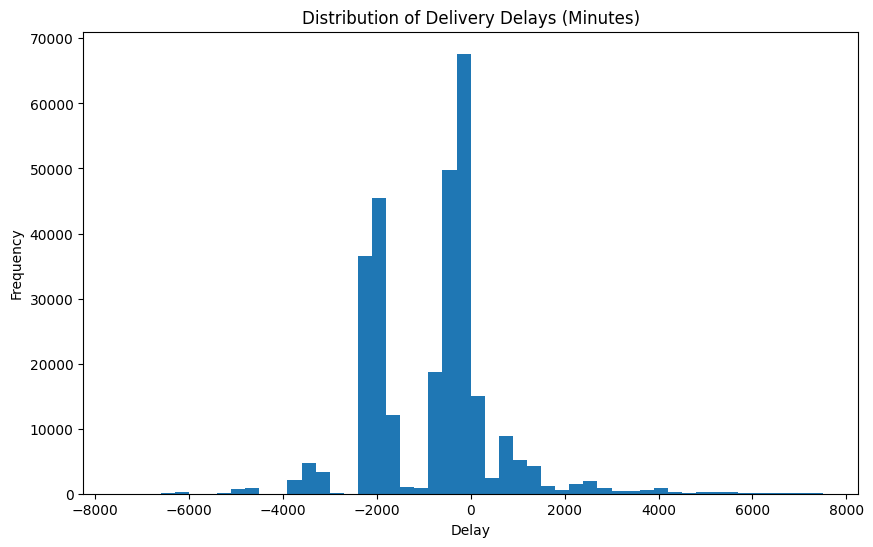

In [9]:
def calc_exp_arr(row):
    ot = row['order_time']
    p_days = row['promise_days']
    if p_days == 1:
        if ot.hour < 11:
            return datetime(ot.year, ot.month, ot.day, 23, 59, 0)
        else:
            next_day = ot + timedelta(days=1)
            return datetime(next_day.year, next_day.month, next_day.day, 15, 0, 0)
    else:
        target_day = ot + timedelta(days=p_days)
        return datetime(target_day.year, target_day.month, target_day.day, 23, 59, 0)

del_data['exp_arr_time'] = del_data.apply(calc_exp_arr, axis=1)
del_data['delay'] = (del_data['arr_time'] - del_data['exp_arr_time']).dt.total_seconds() / 60

# Visualizations
plt.figure(figsize=(10, 6))
plt.hist(del_data['delay'], bins=50, range=(-7500, 7500))
plt.title('Distribution of Delivery Delays (Minutes)')
plt.xlabel('Delay')
plt.ylabel('Frequency')
plt.show()

In [10]:
# Describe delay in days by promise_days
del_data['delay_days'] = del_data['delay'] / (60 * 24)
print("Summary of delay (days) by promise_days:")
print(del_data.groupby('promise_days')['delay_days'].describe())

# Same day delivery focus (dsd)
dsd = del_data[del_data['promise_days'] == 1].copy()
dsd['diffdc'] = (dsd['dc_ori'] != dsd['dc_des']).astype(int)
dsd['hour'] = dsd['order_time'].dt.hour
dsd['lasthour'] = dsd['hour'].isin([10, 22]).astype(int)
dsd['thirdparty'] = (dsd['type_x'] == 2).astype(int)

# Regression Model 1: Standard OLS
model1 = smf.ols('delay ~ sku_cnt + tot_qty + diffdc + lasthour + thirdparty', data=dsd).fit()
print(model1.summary())

# Regression Model 2: Robust Standard Errors (HC3)
# Fixed: Added .fit() before calling get_robustcov_results
model2 = smf.ols('delay ~ sku_cnt + tot_qty + diffdc + lasthour + thirdparty', data=dsd).fit().get_robustcov_results(cov_type='HC3')
print(model2.summary())

Summary of delay (days) by promise_days:
                 count      mean       std       min       25%       50%  \
promise_days                                                               
1.0           139226.0  0.049377  0.703102 -1.290972 -0.249306 -0.166667   
2.0            97530.0 -1.055592  0.762622 -2.624306 -1.499306 -1.332639   
3.0            26353.0 -0.937070  0.926676 -3.332639 -1.499306 -1.290972   
4.0            17291.0 -1.311800  1.118884 -3.624306 -2.207639 -1.457639   
5.0             6948.0 -1.698092  1.490744 -5.290972 -2.499306 -1.624306   
6.0             1842.0 -1.982137  1.630720 -5.249306 -3.207639 -2.290972   
7.0              802.0 -1.979407  2.002390 -6.582639 -3.332639 -2.290972   
8.0             1568.0 -1.091381  3.728095 -8.290972 -3.457639 -1.582639   

                   75%        max  
promise_days                       
1.0           0.041667  21.459028  
2.0          -0.540972  15.417361  
3.0          -0.457639  15.542361  
4.0          -0.58

In [11]:
dsd.to_csv('dsd.csv', index=True)
print("Data exported to dsd.csv")

Data exported to dsd.csv
